# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Linear models assume the outcome is a straight-line function of the predictors, which isn't realistic for a lot of problems, especially things like binary outcomes or bounded values. General linear models, latent variable models, and activation functions let us bring in nonlinearity and map predictions into the right kind of space (like probabilities between 0 and 1). The advantage is flexibility, we can handle outcomes that linear regression just isn't built for.
2. Binary and categorical cross entropy work well because they directly measure how far off the predicted probabilities are from the actual class labels. They penalize confident wrong predictions heavily and reward confident correct ones, which is exactly what we want when training a classifier. They also pair nicely with the sigmoid and softmax outputs of logistic regression, giving a convex loss that's easy to optimize.
3. This is true. Even though logistic regression outputs probabilities through a nonlinear sigmoid, the underlying model is linear in the coefficients. The log-odds of the outcome are a linear combination of the predictors, so it's still considered a linear model.
4. This is false. Logistic regression is actually one of the most common models used for classification. It outputs probabilities, and you can turn those into class predictions by applying a threshold (usually 0.5). So it absolutely can be used for classification, that's basically its main use case.
5. No, the coefficient represents the change in the log-odds of the outcome for a 1 unit change in the predictor, not the change in the predicted probability itself. The relationship between the predictor and the probability is nonlinear because of the sigmoid, so the actual change in predicted probability depends on where you are on the curve.
6. This is false. Logistic regression is nonlinear in its output, but it's still linear in how the predictors combine, so feature engineering matters just as much here as it does for linear regression. Things like interactions, polynomial terms, and transformations can still improve the model a lot.
7. This is false. Logistic regression is built for classification problems with binary or categorical outcomes, while ordinary least squares is meant for continuous outcomes. Using logistic regression on a continuous target doesn't really make sense, and OLS is still the right tool when you're predicting something like price or temperature. The two models are built for different jobs.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('./data/data.csv', sep=';')

cols_needed = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
               'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df_raw[cols_needed].copy()

print(df.isna().sum())
df = df.dropna()

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print(df.shape)
df.head()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
(4424, 7)


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


2.

In [3]:
from sklearn.linear_model import LogisticRegression

predictors = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[predictors]
y = df['dropout']

logit_model = LogisticRegression(max_iter=1000).fit(X, y)

pd.DataFrame({'feature': predictors, 'coefficient': logit_model.coef_[0]})

,feature,coefficient
0,Debtor,0.530625
1,Tuition fees up to date,-2.556542
2,Scholarship holder,-1.227442
3,Age at enrollment,0.049925


3.

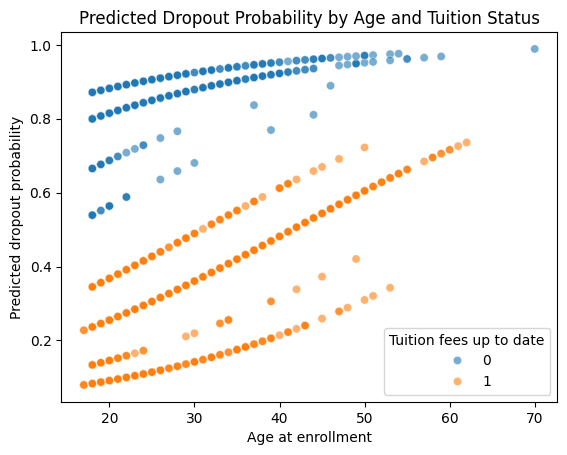

Avg dropout prob, tuition up to date: 0.248
Avg dropout prob, not up to date: 0.861
Difference: 0.613


In [4]:
dropout_probs = logit_model.predict_proba(X)[:, 1]

fig, ax = plt.subplots()
sns.scatterplot(x=df['Age at enrollment'], y=dropout_probs,
                hue=df['Tuition fees up to date'], ax=ax, alpha=0.6)
ax.set_xlabel('Age at enrollment')
ax.set_ylabel('Predicted dropout probability')
ax.set_title('Predicted Dropout Probability by Age and Tuition Status')
plt.show()

avg_up_to_date = dropout_probs[df['Tuition fees up to date'] == 1].mean()
avg_not_up_to_date = dropout_probs[df['Tuition fees up to date'] == 0].mean()
print(f'Avg dropout prob, tuition up to date: {avg_up_to_date:.3f}')
print(f'Avg dropout prob, not up to date: {avg_not_up_to_date:.3f}')
print(f'Difference: {avg_not_up_to_date - avg_up_to_date:.3f}')

4.

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = logit_model.predict(X)
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print('Confusion matrix:')
print(cm)
print(f'Accuracy: {acc:.3f}')

Confusion matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.762


5.

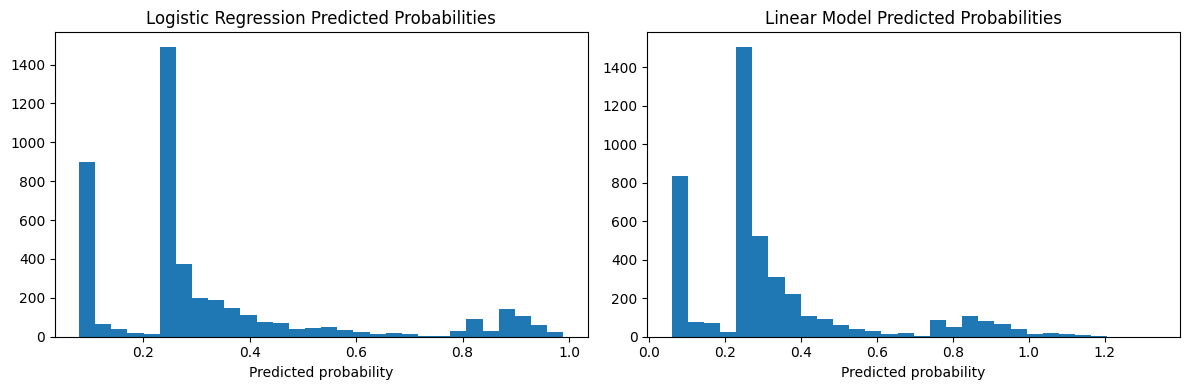

Linear model predicted prob range: [0.058, 1.335]
Logistic predicted prob range: [0.079, 0.989]


In [6]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression().fit(X, y)
linear_probs = linear_model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dropout_probs, bins=30)
axes[0].set_title('Logistic Regression Predicted Probabilities')
axes[0].set_xlabel('Predicted probability')
axes[1].hist(linear_probs, bins=30)
axes[1].set_title('Linear Model Predicted Probabilities')
axes[1].set_xlabel('Predicted probability')
plt.tight_layout()
plt.show()

print(f'Linear model predicted prob range: [{linear_probs.min():.3f}, {linear_probs.max():.3f}]')
print(f'Logistic predicted prob range: [{dropout_probs.min():.3f}, {dropout_probs.max():.3f}]')

6. At-risk learners appear to be the more mature applicants, the learners with outstanding debt, the learners who are late with their tuition fees, and those learners who lack scholarships. This suggests that the main factors contributing to the risk are financial pressure and maturity. Possible interventions may include establishing an emergency fund for financially strapped students to pay tuition, offering scholarships to students with debt, offering online learning options for mature learners balancing school and family responsibilities, and actively pursuing students who are late with tuition payments.

7.

In [8]:
multi_predictors = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = df_raw[multi_predictors]
y_multi = df_raw['Target']

multi_model = LogisticRegression(max_iter=1000).fit(X_multi, y_multi)

y_multi_pred = multi_model.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=multi_model.classes_)

print('Classes:', multi_model.classes_)
print('Confusion matrix:')
print(pd.DataFrame(cm_multi, index=multi_model.classes_, columns=multi_model.classes_))

multi_probs = multi_model.predict_proba(X_multi)
print('\nSample of predicted probabilities:')
print(pd.DataFrame(multi_probs, columns=multi_model.classes_).head(10))

print('\nClasses present in hard predictions:', np.unique(y_multi_pred))
print('Min predicted probability per class:')
print(pd.DataFrame(multi_probs, columns=multi_model.classes_).min())

Classes: ['Dropout' 'Enrolled' 'Graduate']
Confusion matrix:
          Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Sample of predicted probabilities:
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104
5  0.308421  0.323433  0.368146
6  0.071938  0.140644  0.787418
7  0.952988  0.041199  0.005813
8  0.117808  0.176983  0.705209
9  0.838886  0.122977  0.038136

Classes present in hard predictions: ['Dropout' 'Graduate']
Min predicted probability per class:
Dropout     9.564711e-07
Enrolled    2.789661e-04
Graduate    2.135320e-03
dtype: float64


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

1.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('./data/cirrhosis.csv', sep=None, engine='python')
df_raw.columns = df_raw.columns.str.strip()

print(df_raw.columns.tolist())
print(df_raw.shape)
df_raw.head()

['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
(418, 20)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


2.

In [25]:
from sklearn.linear_model import LogisticRegression

predictors = ['edema_S', 'edema_Y', 'drug_active', 'Bilirubin']
X = df[predictors]
y = df['survived']

logit_model = LogisticRegression(max_iter=1000).fit(X, y)

pd.DataFrame({'feature': predictors, 'coefficient': logit_model.coef_[0]})

,feature,coefficient
0,edema_S,-0.451483
1,edema_Y,-1.613160
2,drug_active,-0.231952
3,Bilirubin,-0.351450


3.

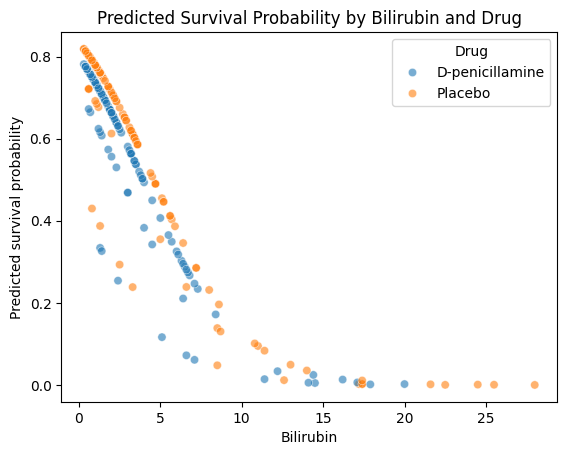

Avg survival prob on drug: 0.590
Avg survival prob on placebo: 0.609
Difference: -0.019


In [26]:
survival_probs = logit_model.predict_proba(X)[:, 1]

fig, ax = plt.subplots()
sns.scatterplot(x=df['Bilirubin'], y=survival_probs,
                hue=df['Drug'], ax=ax, alpha=0.6)
ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted survival probability')
ax.set_title('Predicted Survival Probability by Bilirubin and Drug')
plt.show()

avg_drug = survival_probs[df['drug_active'] == 1].mean()
avg_placebo = survival_probs[df['drug_active'] == 0].mean()
print(f'Avg survival prob on drug: {avg_drug:.3f}')
print(f'Avg survival prob on placebo: {avg_placebo:.3f}')
print(f'Difference: {avg_drug - avg_placebo:.3f}')

4.

In [28]:
y_pred = logit_model.predict(X)
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print('Confusion matrix:')
print(cm)
print(f'Accuracy: {acc:.3f}')

Confusion matrix:
[[ 59  66]
 [ 16 171]]
Accuracy: 0.737


5.

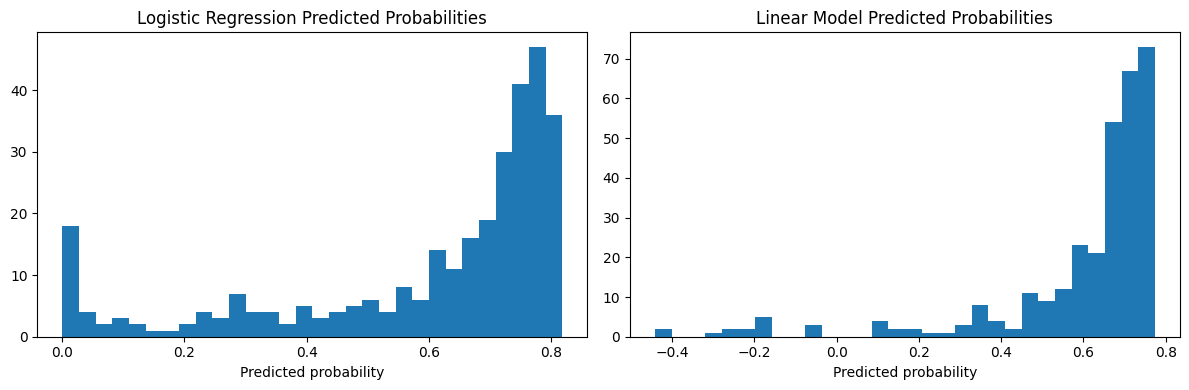

Linear model range: [-0.442, 0.774]
Logistic range: [0.000, 0.818]


In [29]:
linear_model = LinearRegression().fit(X, y)
linear_probs = linear_model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(survival_probs, bins=30)
axes[0].set_title('Logistic Regression Predicted Probabilities')
axes[0].set_xlabel('Predicted probability')
axes[1].hist(linear_probs, bins=30)
axes[1].set_title('Linear Model Predicted Probabilities')
axes[1].set_xlabel('Predicted probability')
plt.tight_layout()
plt.show()

print(f'Linear model range: [{linear_probs.min():.3f}, {linear_probs.max():.3f}]')
print(f'Logistic range: [{survival_probs.min():.3f}, {survival_probs.max():.3f}]')

6.

In [30]:
stage_predictors = ['edema_S', 'edema_Y', 'Bilirubin']
X_stage = df[stage_predictors]
y_stage = df['Stage']

stage_model = LogisticRegression(max_iter=1000).fit(X_stage, y_stage)

y_stage_pred = stage_model.predict(X_stage)
cm_stage = confusion_matrix(y_stage, y_stage_pred, labels=stage_model.classes_)

print('Classes:', stage_model.classes_)
print('Confusion matrix:')
print(pd.DataFrame(cm_stage, index=stage_model.classes_, columns=stage_model.classes_))

stage_probs = stage_model.predict_proba(X_stage)
print('\nSample of predicted probabilities:')
print(pd.DataFrame(stage_probs, columns=stage_model.classes_).head(10))

print('\nClasses present in hard predictions:', np.unique(y_stage_pred))
print('Min predicted probability per class:')
print(pd.DataFrame(stage_probs, columns=stage_model.classes_).min())

Classes: [1. 2. 3. 4.]
Confusion matrix:
     1.0  2.0  3.0  4.0
1.0    0    0   16    0
2.0    0    0   63    4
3.0    0    0  105   15
4.0    0    0   79   30

Sample of predicted probabilities:
        1.0       2.0       3.0       4.0
0  0.000013  0.032535  0.143611  0.823841
1  0.072394  0.251555  0.397520  0.278531
2  0.029263  0.181531  0.395694  0.393512
3  0.023272  0.176777  0.397217  0.402734
4  0.020204  0.224965  0.423342  0.331488
5  0.084886  0.253397  0.391412  0.270305
6  0.076359  0.252233  0.395575  0.275833
7  0.110046  0.255032  0.379260  0.255662
8  0.022637  0.227782  0.422181  0.327400
9  0.000042  0.040292  0.153955  0.805712

Classes present in hard predictions: [3. 4.]
Min predicted probability per class:
1.0    2.982598e-09
2.0    1.289929e-02
3.0    1.045275e-01
4.0    2.556618e-01
dtype: float64


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

1. The derivative of the prediction with respect to the $k$-th feature is

$$\frac{\partial \hat{y}}{\partial x_k} = b_k.$$

For a 1 unit change in $x_k$, the prediction changes by exactly $b_k$. The coefficient directly gives you the marginal effect, which is the nice thing about linear regression. It's constant everywhere, so the interpretation doesn't depend on the values of the other features.

2. Using the chain rule on the sigmoid, the derivative of the predicted probability with respect to $x_k$ is

$$\frac{\partial \hat{p}_i}{\partial x_k} = b_k \cdot \hat{p}_i(1 - \hat{p}_i).$$

Yes, the answer changes as $x$ changes, because it depends on $\hat{p}_i$ itself. Unlike the linear case where the marginal effect is constant, here the effect of a 1 unit change in $x_k$ on the predicted probability depends on where you are on the sigmoid curve. The effect is largest when $\hat{p}_i = 0.5$ (since $\hat{p}_i(1 - \hat{p}_i) = 0.25$, its maximum) and shrinks toward zero when $\hat{p}_i$ is near 0 or 1.

The coefficient times $1/4$ is roughly a good estimate of how a change in $x_k$ affects the prediction when $\hat{p}_i$ is near $0.5$, since that's where $\hat{p}_i(1 - \hat{p}_i)$ hits its max of $0.25$. So $b_k / 4$ gives you an upper bound on the marginal effect on probability.

3. A one unit change in $x_k$ changes the log odds ratio by exactly $b_k$. Since

$$\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x,$$

the coefficient $b_k$ is constant and doesn't depend on the values of the other features. This is the cleanest way to interpret logistic regression coefficients. They're linear in the log odds, even though they're nonlinear in the probability. Exponentiating gives $e^{b_k}$, which is the multiplicative change in the odds ratio for a 1 unit change in $x_k$.